---
title: "Smoothing of credit card operations using time series techniques"
date: "2025-01-30"
categories: [Time Series, R, Payment Systems, Card Payments]
description: ""
image: "preview.png"
---

## Introduction

Time series smoothing is a technique that removes random and seasonal elements from a time series to obtain its general trend.

This technique can be used to track the evolution of credit and debit card payment operations at point-of-sale terminals processed by card payment clearing houses in Mexico.

This article presents various smoothing techniques for the number of credit and debit card operations at point-of-sale terminals. For this purpose, we will use the API of Banco de México's Sistema de Información Económica (SIE) and R libraries to apply the following smoothing techniques:

 - Moving average
 - Exponential smoothing
 - Seasonal-Trend decomposition using LOESS (STL)
 - Dynamic Linear Model (DLM)


Fot this notebook we will make use of the following libraries:

In [8]:
library(dotenv) # To load environment variables
library(here) # To search for files easily
library(tidyverse) # For data manipumation
library(ggplot2)
source(here("R", "sie_utils.R")) 

## 1. Data gathering

The data comes from Banco de México's Sistema de Información Económica (SIE), which provides an API for programmatic data retrieval.

To use the API, an authentication token is required, which can be requested on [this Banco de México webpage](https://www.banxico.org.mx/SieAPIRest/service/v1/token).

A secure way to store the token is through environment variables, which prevents exposing sensitive credentials directly in the code. To do this, create a `.env` file in the project's root directory where the token is stored in the format `BANXICO_TOKEN=your_token_here`. Although the API token is free and does not incur any costs, it is good practice not to share it with third parties.

Once the `.env` file is in the project's root directory, it can be loaded in R using the `dotenv` library, which reads the `.env` file and makes its values available through the `Sys.getenv()` function. For example, to retrieve the authentication token, you can use the following code:

In [6]:
load_dot_env(here(".env"))
sie_token <- Sys.getenv("SIE_TOKEN")

Once the SIE API token has been loaded, we can proceed to retrieve the data. We will obtain two time series: one for debit card operations and another for credit card operations.

To accomplish this, we will use  a custmom function called `get_sie_series` that makes use R's `httr` and `jsonlite` librarie. If you want to view the details, you can see the repo folder named **R** that contains an R file called sie_utils.R. 

In [7]:
df_debit <- get_sie_series("SF351178", sie_token)
df_credit <- get_sie_series("SF351179", sie_token)

# Join series in one df
df_ops <- left_join(df_debit, df_credit, by="fecha") |>
    filter(fecha >= as.Date("2023-01-01")) |>
    filter(fecha <= as.Date("2025-12-31"))


colnames(df_ops) <- c("date", "debit", "credit")
df_ops <- df_ops |>
mutate(debit = debit / 1000000,
           credit = credit/ 1000000)

head(df_ops)


,date,debit,credit
,<date>,<dbl>,<dbl>
1,2023-01-01,16.07771,5.088792
2,2023-01-02,10.67967,3.936692
3,2023-01-03,14.68352,5.650967
4,2023-01-04,14.35926,5.485605
5,2023-01-05,14.79250,5.621567
6,2023-01-06,15.51339,5.761273


For this exercise, we only use information from january 2023 to december 2025, i.e., three years

## 2. Exploratory Data Analysis

Before we apply any smoothing technique (just as with any other data project), it's essential to get a good understanding of the data in order to choose an appropiate modelling approach.

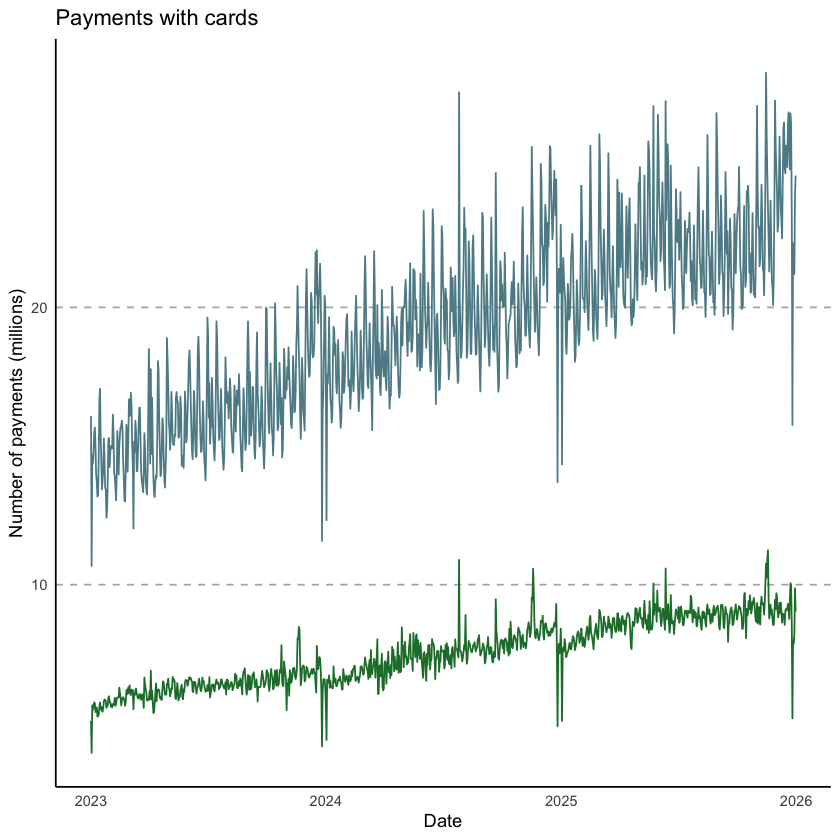

In [ ]:
ggplot(data = df_ops, aes(x=date, y = debit)) +
    geom_line(color="#5d8b96") +
    geom_line(aes(x=date, y = credit), color="#1d7d36") + 
    theme_minimal() + 
    theme(
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        panel.grid.major.y = element_line(linetype="dashed", color = "gray70"),
        panel.grid.minor.y = element_blank(),
        axis.line = element_line(color="black")
    ) +
    labs(title = "Payments with cards",
        y = "Number of payments (millions)", 
        x= "Date"
        )